# GO proposal for White Dwarf (WD) pulsators

This notebook is used to prepare the GO proposal for white dwarf (WD) pulsators.

- Author: Nicholas Jannsen
- Last check: 2026-02-15
- PlatoSim develop branch: `3.7.0-191-g42fc64d4`

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
# Built-in
import os
import sys
import glob

# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# PlatoSim libraries
import platosim.plot      as pt
import platosim.utilities as ut
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [6]:
# Set global paths
hdir = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles/data_picsim'
path = Path(os.getenv('PLATO_WORKDIR')) / 'go_WD'
idir = path / 'input'
fdir = path / 'figures'

---
## 1. Stellar catalogue
---

### Show catalogues

In [49]:
# Load WD stars
df_dav = pd.read_csv(idir / 'DAVs_LOPS2.csv')
df_dbv = pd.read_csv(idir / 'DBVs_LOPS2.csv')
# print(df.columns.tolist())
df_dav.head()

,WDJ_name,designation,ra_1,ra_error,dec_1,dec_error,parallax,parallax_error,parallax_over_error,ZP_correction,...,M,M_low,M_upp,L_2a,L_low,L_upp,spec,evol,Separation_2,Separation
0,WDJ041930.81-352046.73,Gaia EDR3 4870090943381248128,64.878162,0.034393,-35.346489,0.043910,11.227818,0.047526,236.24644,-0.028021,...,NaN,NaN,NaN,NaN,NaN,NaN,B,NaN,1.558396e-08,1.768571e-10
1,WDJ045359.85-432247.75,Gaia EDR3 4811871287295222016,73.501550,0.042615,-43.379587,0.041084,7.898824,0.046184,171.02765,-0.026139,...,NaN,NaN,NaN,NaN,NaN,NaN,F,NaN,3.385557e-09,9.159997e-11
2,WDJ045405.87-342505.71,Gaia EDR3 4873109308958466432,73.524457,0.025562,-34.418209,0.030441,13.329992,0.033365,399.51930,-0.027899,...,NaN,NaN,NaN,NaN,NaN,NaN,B,NaN,2.024354e-08,1.870553e-10
3,WDJ045551.33-705541.81,Gaia EDR3 4654695103690489856,73.965790,0.035661,-70.928558,0.039658,12.775774,0.038939,328.10043,-0.031998,...,NaN,NaN,NaN,NaN,NaN,NaN,B,NaN,9.988990e-09,1.886207e-10
4,WDJ052518.96-302018.13,Gaia EDR3 2905372374461903488,81.329208,0.032407,-30.338298,0.039506,9.481599,0.044091,215.04636,-0.023451,...,NaN,NaN,NaN,NaN,NaN,NaN,F,NaN,6.323392e-09,1.207750e-10


<IPython.core.display.Javascript object>


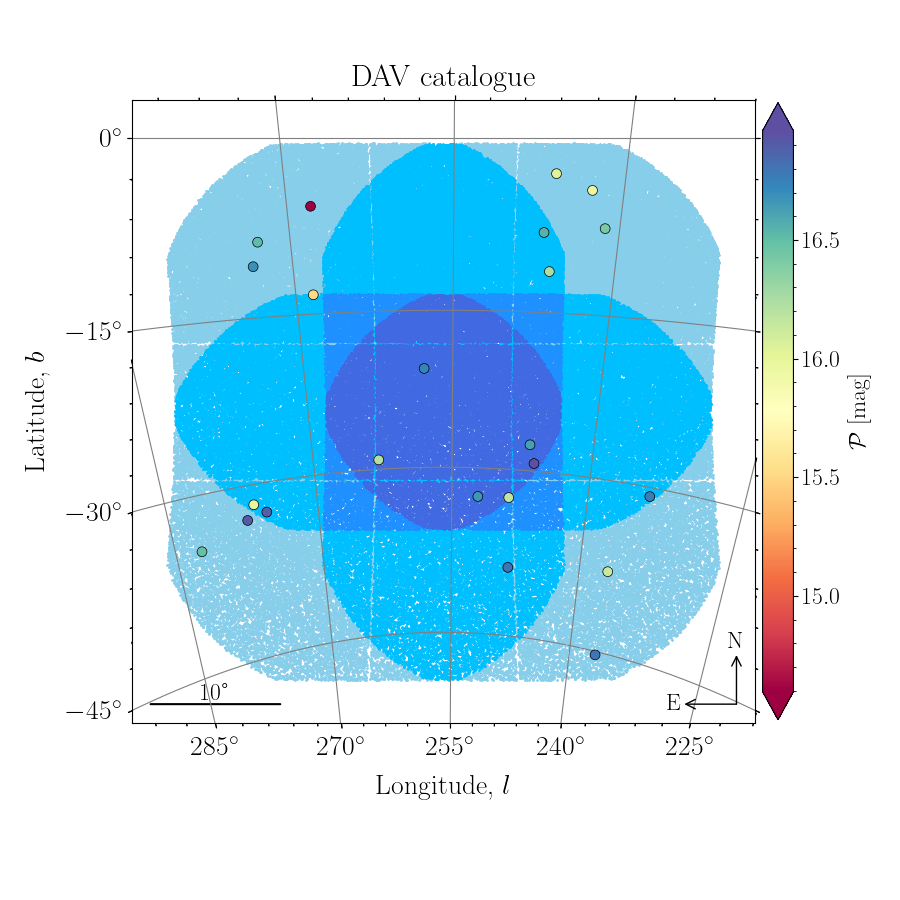

In [52]:
# Plot DAV targets in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=df_dav.ra_1, decStars=df_dav.dec_1, c=df_dav.phot_g_mean_mag,
    clabel=r'$\mathcal{P}$ [mag]', s=200, lw=0.5,
    title='DAV catalogue', figsize=(9,9),
)
fig.savefig(fdir / f'starcat_sky_DAVs_NCAM.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


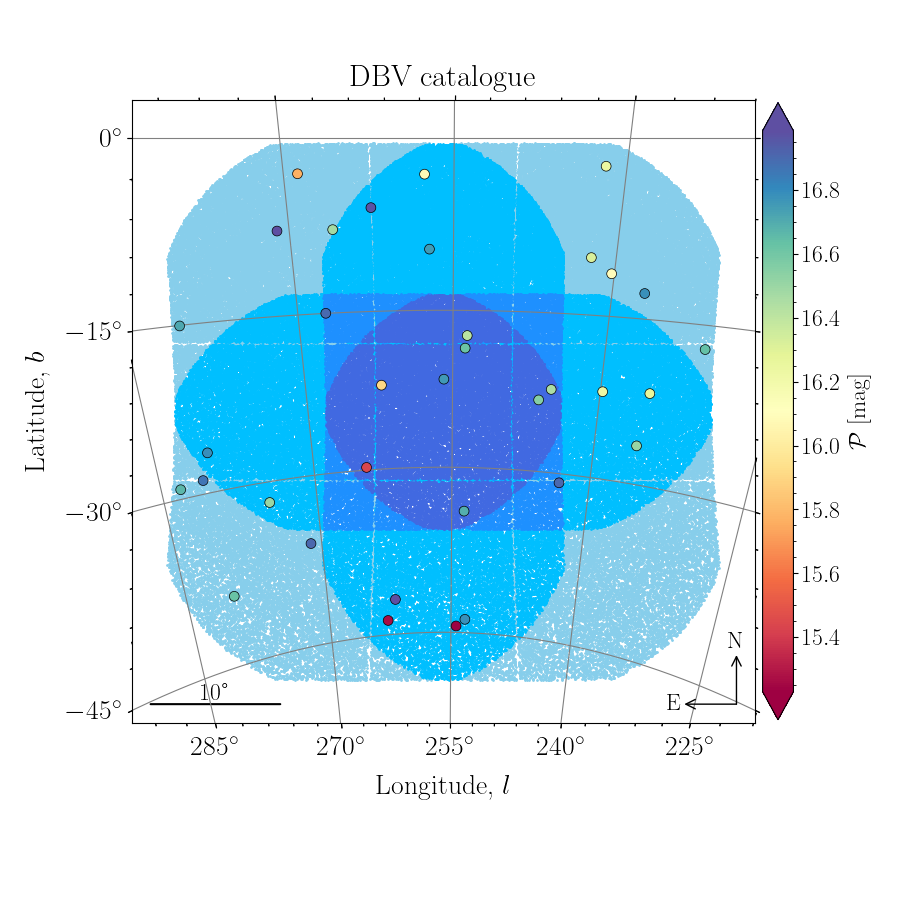

In [53]:
# Plot DBV targets in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=df_dbv.ra_1, decStars=df_dbv.dec_1, c=df_dbv.phot_g_mean_mag,
    clabel=r'$\mathcal{P}$ [mag]', s=200, lw=0.5,
    title='DBV catalogue', figsize=(9,9),
)
fig.savefig(fdir / f'starcat_sky_DBVs_NCAM.png', bbox_inches='tight', dpi=200)

### Cross-match with F-CAM sources

In [57]:
# Load PLATO-CS catalogue
ds = pd.read_feather(hdir / 'PlatoCS_FCAM_LOPS2.ftr')
ds.gaiaDR3 = ds.gaiaDR3.astype('int64')
ds.head()

,gaiaDR3,ra,dec,Gmag,BP_RP,Ag,plx,plx_err,pmra,pmdec,...,S_err,spec,evol,variable,class,ncams,Pmag,Pgiant,PBmag,PRmag
0,5502164890740285696,102.484267,-50.614848,2.618499,1.312425,NaN,18.757713,0.347519,32.618184,-69.565734,...,NaN,G,<NA>,NOT_AVAILABLE,,6,2.282788,2.277100,2.718279,1.864839
1,2896572746685604480,95.078337,-30.063349,3.007651,0.069759,NaN,9.492206,0.447933,6.084451,4.247413,...,NaN,B,<NA>,NOT_AVAILABLE,,6,2.982762,2.982928,2.998538,2.960518
2,5478862906452936960,102.047058,-61.940116,3.203374,0.458191,NaN,NaN,NaN,NaN,NaN,...,NaN,A,<NA>,NOT_AVAILABLE,,6,3.053324,3.053446,3.168014,2.906023
3,5557271829408912896,99.440299,-43.195953,3.175233,0.098825,NaN,8.819389,0.288251,-0.537264,-3.858982,...,NaN,B,<NA>,NOT_AVAILABLE,,6,3.140169,3.140392,3.162667,3.108633
4,4757601523650165120,83.406311,-62.489769,3.593462,1.049574,0.3925,2.930785,0.139114,-0.611187,12.949733,...,NaN,F,<NA>,NOT_AVAILABLE,,6,3.302200,3.298827,3.620285,2.965348


In [58]:
# Creaet new column to match with Gaia DR3 IDs
df_dav['gaiaDR3'] = df_dav.designation.str[10:].astype('int64')
df_dbv['gaiaDR3'] = df_dbv.designation.str[10:].astype('int64')

In [62]:
# Cross-match with catalogues
dt_dav = df_dav[df_dav['gaiaDR3'].isin(ds['gaiaDR3'])].sort_values(by='phot_g_mean_mag')
dt_dav.phot_g_mean_mag

6     16.170313
12    16.213686
11    16.627130
7     16.661581
13    16.734783
1     16.821110
10    16.961120
Name: phot_g_mean_mag, dtype: float64

In [63]:
# Cross-match with catalogues
dt_dbv = df_dbv[df_dbv['gaiaDR3'].isin(ds['gaiaDR3'])].sort_values(by='phot_g_mean_mag')
dt_dbv.phot_g_mean_mag

7     15.440610
17    15.906223
11    16.228355
20    16.414644
13    16.450840
5     16.502954
12    16.547990
19    16.616377
34    16.693764
25    16.746212
Name: phot_g_mean_mag, dtype: float64

<IPython.core.display.Javascript object>


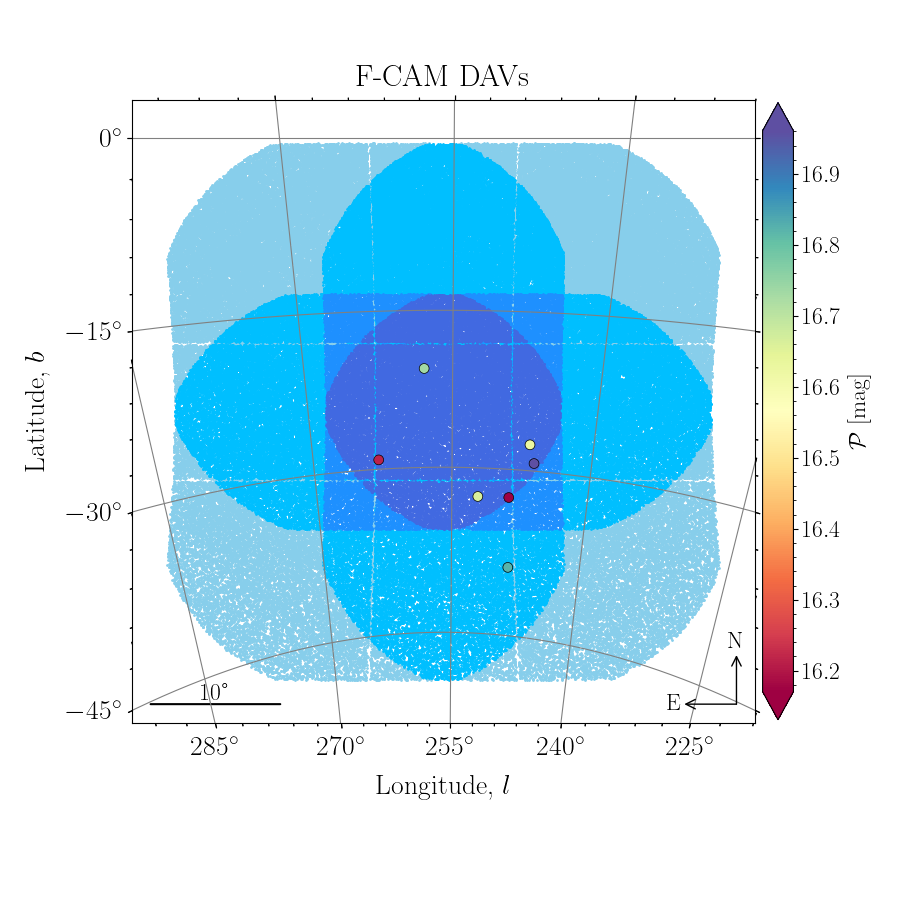

In [64]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dt_dav.ra_1, decStars=dt_dav.dec_1, c=dt_dav.phot_g_mean_mag,
    clabel=r'$\mathcal{P}$ [mag]', s=200, lw=0.5,
    title='F-CAM DAVs ', figsize=(9,9),
)
fig.savefig(fdir / f'starcat_sky_DAVs_FCAM.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


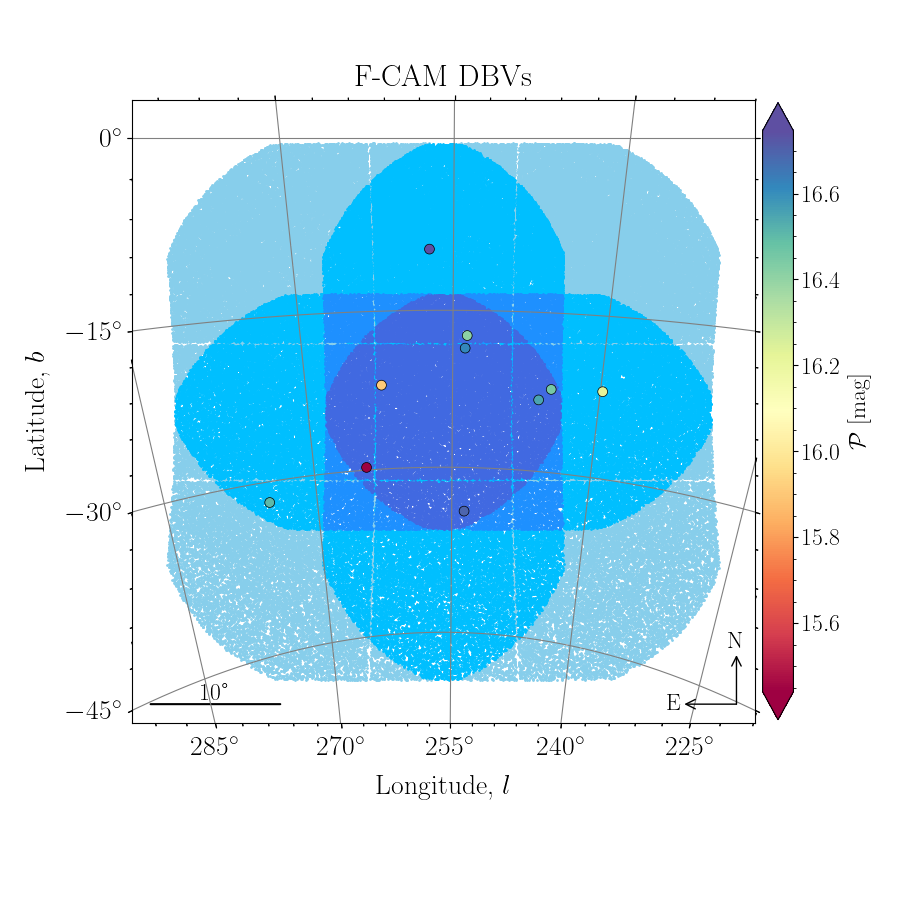

In [65]:
# Plot target in Galactic projection
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=30, ncamStars=True,
    raStars=dt_dbv.ra_1, decStars=dt_dbv.dec_1, c=dt_dbv.phot_g_mean_mag,
    clabel=r'$\mathcal{P}$ [mag]', s=200, lw=0.5,
    title='F-CAM DBVs ', figsize=(9,9),
)
fig.savefig(fdir / f'starcat_sky_DBVs_FCAM.png', bbox_inches='tight', dpi=200)

We can conclude that all proposed WDs are too faint to be followed up by the F-CAMs.